# **Data Presprocessing:**

In [263]:
!pip install datasets

In [264]:
!pip install nltk emoji

In [265]:
import nltk
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to C:\Users\Arwa
[nltk_data]     Mohamed\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Read dataset from datasets package

In [266]:
from datasets import load_dataset
dataset = load_dataset("tweet_eval", "sentiment")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [267]:
dataset['train'][0]

{'text': '"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"',
 'label': 2}

Converted it into a pandas dataframe for easier manipulation

Labels: 0 -> negative
        1 -> neutral
        2 -> positive

In [268]:
import pandas as pd

df_train = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])
df_val = pd.DataFrame(dataset['validation'])
df_train.head()

,text,label
0,"""QT @user In the original draft of the 7th boo...",2
1,"""Ben Smith / Smith (concussion) remains out of...",1
2,Sorry bout the stream last night I crashed out...,1
3,Chase Headley's RBI double in the 8th inning o...,1
4,@user Alciato: Bee will invest 150 million in ...,2


In [269]:
print(f"The shape of train set : {df_train.shape}")
print(f"The shape of test set : {df_test.shape}")
print(f"The shape of validation set : {df_val.shape}")

The shape of train set : (45615, 2)
The shape of test set : (12284, 2)
The shape of validation set : (2000, 2)


Data cleaning and preprocessing:

In [270]:
import re
import nltk
import emoji
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [271]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to C:\Users\Arwa
[nltk_data]     Mohamed\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Arwa
[nltk_data]     Mohamed\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Arwa
[nltk_data]     Mohamed\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [272]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 3.4 MB/s eta 0:00:04
     ---- ----------------------------------- 1.3/12.8 MB 3.7 MB/s eta 0:00:04
     ------ --------------------------------- 2.1/12.8 MB 3.8 MB/s eta 0:00:03
     --------- ------------------------------ 2.9/12.8 MB 3.8 MB/s eta 0:00:03
     ----------- ---------------------------- 3.7/12.8 MB 3.8 MB/s eta 0:00:03
     ------------- -------------------------- 4.5/12.8 MB 3.9 MB/s eta 0:00:03
     --------------- ------------------------ 5.0/12.8 MB 3.9 MB/s eta 0:00:03
     ------------------ --------------------- 6.0/12.8 MB 3.8 MB/s eta 0:00:02
     --------------------- ------------------ 6.8/12.8 MB 3.8 MB/s eta 0:00:02
     ---------------------- ----------------- 7.3/12.8 MB 3.8 MB/s eta 0:00:02
     ------------------------- -------------- 8.1/12.8 MB 3.8 MB/s eta 0:00:02
     --------------------------- ------------ 8.7/12.8 MB 3

In [273]:
import spacy
nlp = spacy.load('en_core_web_sm')

In [274]:
def cleaning(text):
    lemmatizer = WordNetLemmatizer()
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)         # remove URLs
    text = re.sub(r'@\w+', '', text)                            # remove usernames
    text = re.sub(r'#\w+', '', text)                            # remove hashtags
    text = emoji.replace_emoji(text, replace='')                # remove emojis
    text = re.sub(r'\s+', ' ', text)                            #to replace multiple spaces with single one
    doc = nlp(text)
    lemmatized_tokens = [token.lemma_.lower() for token in doc if not token.is_space]
    return lemmatized_tokens

In [275]:
#testing the cleaining function
text1 = "Check out our new product! 😍😍 Visit https://example.com @brand"
text2 = "Loving the #ParisFashionWeek revolution. #ZARA is the future!"
text3 = "Great job @aly 👏👏 on your mark!"
text4 = "This is amazing! Read more at https://news.com #BreakingNews"
text5 = "🔥🔥 I am running better and last week i have looked to run 45 km. #Winning @alexandria"
for i, text in enumerate([text1, text2, text3, text4, text5], 1):
    print(f"Test Case {i}:")
    print(cleaning(text))
    print("-" * 30)

Test Case 1:
['check', 'out', 'our', 'new', 'product', '!', 'visit']
------------------------------
Test Case 2:
['love', 'the', 'revolution', '.', 'be', 'the', 'future', '!']
------------------------------
Test Case 3:
['great', 'job', 'on', 'your', 'mark', '!']
------------------------------
Test Case 4:
['this', 'be', 'amazing', '!', 'read', 'more', 'at']
------------------------------
Test Case 5:
['i', 'be', 'run', 'well', 'and', 'last', 'week', 'i', 'have', 'look', 'to', 'run', '45', 'km', '.']
------------------------------


In [276]:
def remove_extracharacters(tokens):
   # return [re.sub(r'[^\w\s]', '', token) for token in tokens if re.sub(r'[^\w\s]', '', token)]#remove non-word and non-whitespace characters
   return [re.sub(r'[^A-Za-z_]', '', token) for token in tokens if re.sub(r'[^A-Za-z_]', '', token)] #remove non-word and non-whitespace characters and numbers

In [277]:
import nltk
from nltk.corpus import stopwords

# Download stopwords from NLTK
nltk.download('stopwords')
# Get English stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word.lower() not in stop_words]

[nltk_data] Downloading package stopwords to C:\Users\Arwa
[nltk_data]     Mohamed\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [278]:
def extra_cleaning(df):
  df['extra_cleaned'] = df['text'].apply(remove_extracharacters)
  df['extra_cleaned'] = df['extra_cleaned'].apply(remove_stopwords)
  return df

In [279]:
data = {
    'text': [
        ['This', 'is', 'an', 'example!'],
        ['Another', '#tweet', 'with', 'punctuation...'],
        ['Clean', 'this', 'UP', 'PLEASE!!!']
    ]
}
test = pd.DataFrame(data)
print("Before cleaning:\n", test)
test = extra_cleaning(test)
print("\nAfter cleaning:\n", test)

Before cleaning:
                                       text
0                 [This, is, an, example!]
1  [Another, #tweet, with, punctuation...]
2             [Clean, this, UP, PLEASE!!!]

After cleaning:
                                       text                  extra_cleaned
0                 [This, is, an, example!]                      [example]
1  [Another, #tweet, with, punctuation...]  [Another, tweet, punctuation]
2             [Clean, this, UP, PLEASE!!!]                [Clean, PLEASE]


In [280]:
df_train['text'] = df_train['text'].apply(cleaning)
df_test['text'] = df_test['text'].apply(cleaning)
df_val['text'] = df_val['text'].apply(cleaning)

In [281]:
df_train = extra_cleaning(df_train)
df_test = extra_cleaning(df_test)
df_val = extra_cleaning(df_val)

In [282]:
df_train.head()

,text,label,extra_cleaned
0,"["", qt, in, the, original, draft, of, the, 7th...",2,"[qt, original, draft, th, book, remus, lupin, ..."
1,"["", ben, smith, /, smith, (, concussion, ), re...",1,"[ben, smith, smith, concussion, remain, lineup..."
2,"[sorry, bout, the, stream, last, night, i, cra...",1,"[sorry, bout, stream, last, night, crash, toni..."
3,"[chase, headley, 's, rbi, double, in, the, 8th...",1,"[chase, headley, rbi, double, th, inning, davi..."
4,"[alciato, :, bee, will, invest, 150, million, ...",2,"[alciato, bee, invest, million, january, anoth..."


In [283]:
df_test.head()

,text,label,extra_cleaned
0,"[what, do, these, ', 1/2, naked, pic, ', have,...",1,"[naked, pic, anything, even, like]"
1,"[oh, :, "", i, have, a, blue, penis, while, i, ...",1,"[oh, blue, penis, play, google, earth, vr]"
2,"[that, be, come, ,, but, i, think, the, victim...",1,"[come, think, victim, go, medicaid, recipients]"
3,"[i, think, i, may, be, finally, in, with, the,...",2,"[think, may, finally, crowd]"
4,"[wow, ,, first, hugo, chavez, and, now, fidel,...",0,"[wow, first, hugo, chavez, fidel, castro, dann..."


In [284]:
df_val.head()

,text,label,extra_cleaned
0,"[dark, soul, 3, april, launch, date, confirm, ...",1,"[dark, soul, april, launch, date, confirm, new..."
1,"["", national, hot, dog, day, ,, national, tequ...",2,"[national, hot, dog, day, national, tequila, d..."
2,"[when, girl, become, bandwagon, fan, of, the, ...",0,"[girl, become, bandwagon, fan, packer, harry, ..."
3,"[i, may, or, may, not, have, search, it, up, o...",1,"[may, may, search, google]"
4,"[here, be, your, start, tuesday, morning, line...",1,"[start, tuesday, morning, line, gentle, yoga, ..."


# **EDA** -> Exploratory Data Anlaysis

In [285]:
df = df_train.copy()

In [286]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45615 entries, 0 to 45614
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text           45615 non-null  object
 1   label          45615 non-null  int64 
 2   extra_cleaned  45615 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


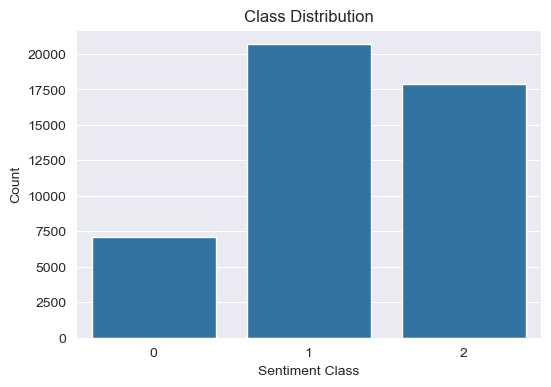

In [287]:
import seaborn as sns
import matplotlib.pyplot as plt
#plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title('Class Distribution')
plt.xlabel('Sentiment Class')
plt.ylabel('Count')
plt.show()

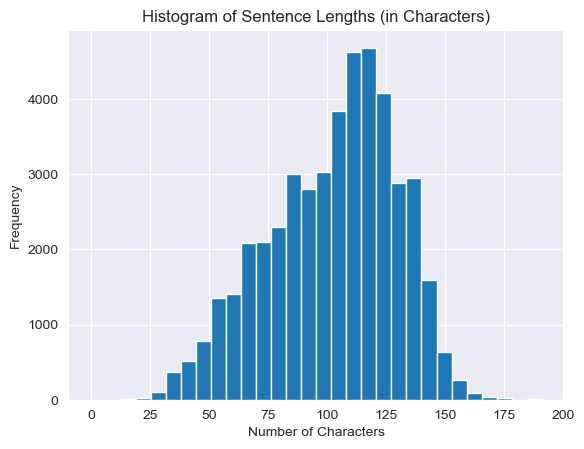

In [288]:
df['text_length'] = df['text'].apply(lambda x: len(' '.join(x)))
#histogram of the number of characters
df['text_length'].hist(bins=30)

plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.title('Histogram of Sentence Lengths (in Characters)')

plt.show()

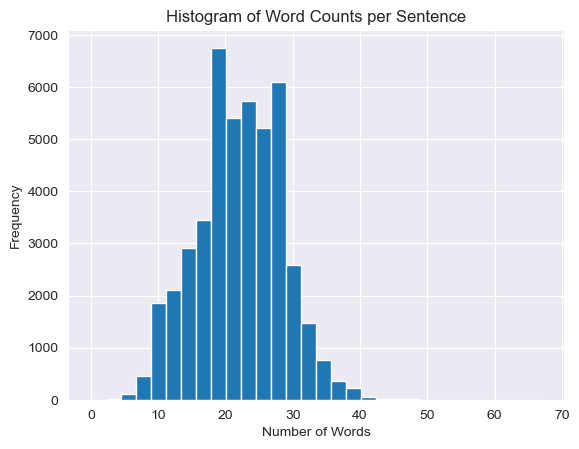

In [289]:
df['word_count'] = df['text'].apply(len)

#histogram of word counts
df['word_count'].hist(bins=30)

plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Histogram of Word Counts per Sentence')

plt.show()

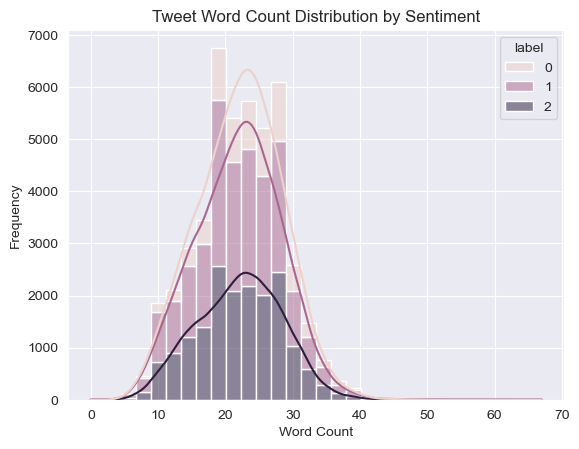

In [290]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x='word_count', hue='label', bins=30, kde=True, multiple='stack')
plt.title("Tweet Word Count Distribution by Sentiment")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

In [291]:
from collections import Counter
import matplotlib.pyplot as plt

def get_top_words(token_lists, n=20):
    all_tokens = [word.lower() for tokens in token_lists for word in tokens if word.isalpha()]
    counter = Counter(all_tokens)
    return counter.most_common(n)

In [292]:
top_words = {}

for sentiment in [0,1,2]:
    tokens = df[df['label'] == sentiment]['text']
    top_words[sentiment] = get_top_words(tokens)

Top words before removing stop words:

C:\Users\Arwa Mohamed\AppData\Local\Temp\ipykernel_1768\1058988975.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), palette='viridis', hue=None, legend=False)


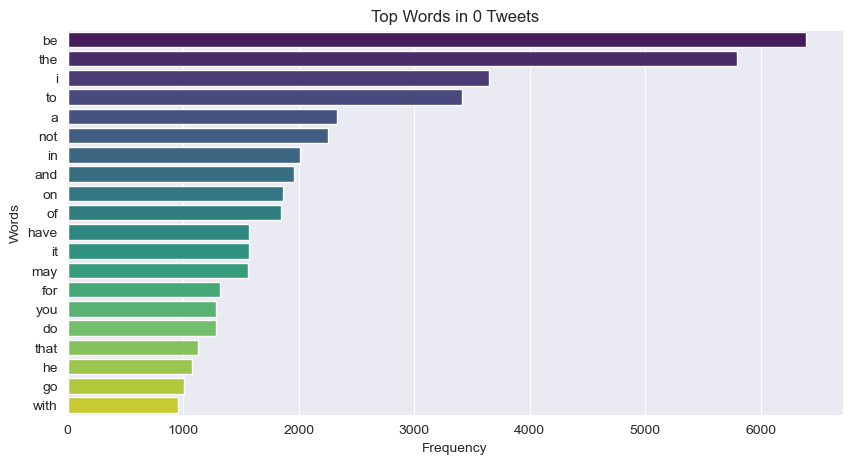

C:\Users\Arwa Mohamed\AppData\Local\Temp\ipykernel_1768\1058988975.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), palette='viridis', hue=None, legend=False)


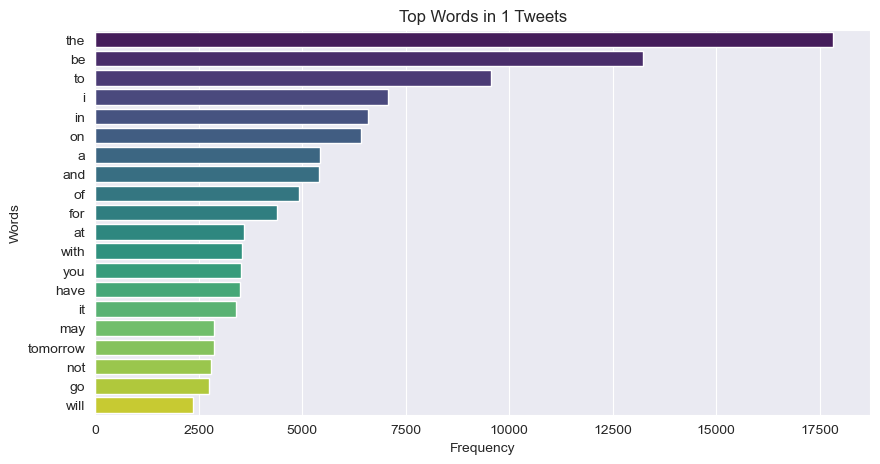

C:\Users\Arwa Mohamed\AppData\Local\Temp\ipykernel_1768\1058988975.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), palette='viridis', hue=None, legend=False)


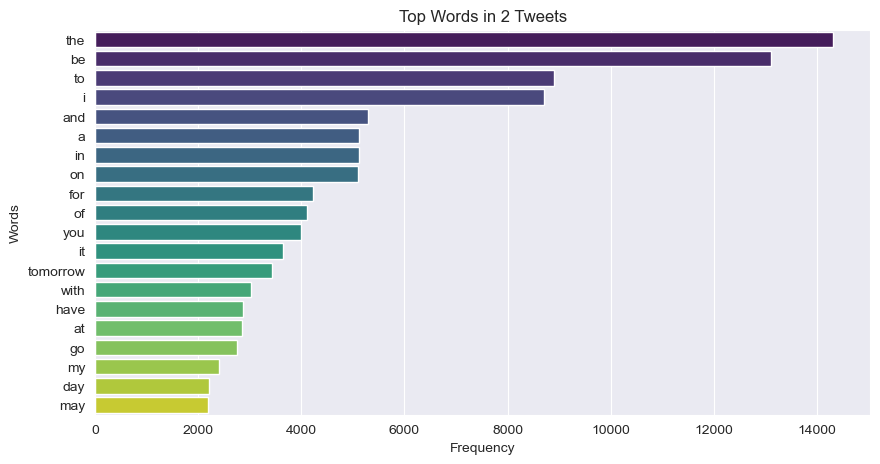

In [293]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_words(word_freq, sentiment):
    words, freqs = zip(*word_freq)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(freqs), y=list(words), palette='viridis', hue=None, legend=False)
    plt.title(f"Top Words in {sentiment} Tweets")
    plt.xlabel("Frequency")
    plt.ylabel("Words")
    plt.show()

# Plot for each sentiment
for sentiment in [0,1,2]:
    plot_top_words(top_words[sentiment], sentiment)


Top words after removing stopping words:

C:\Users\Arwa Mohamed\AppData\Local\Temp\ipykernel_1768\673335096.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), palette='viridis', hue=None, legend=False)


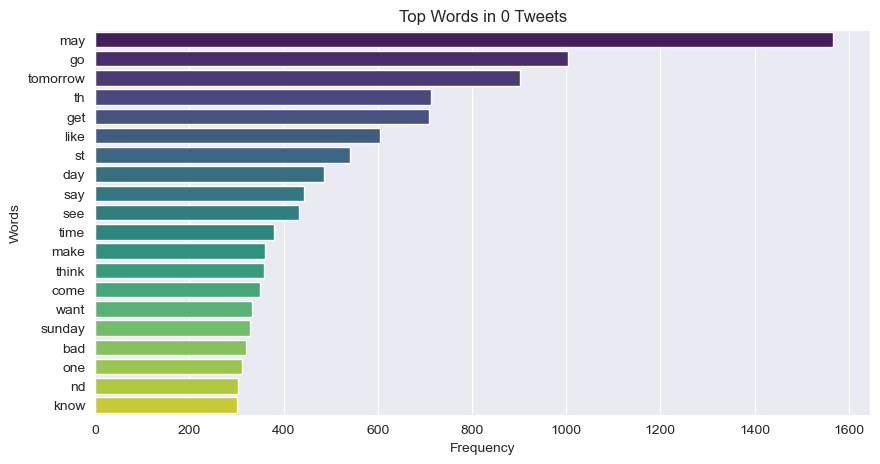

C:\Users\Arwa Mohamed\AppData\Local\Temp\ipykernel_1768\673335096.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), palette='viridis', hue=None, legend=False)


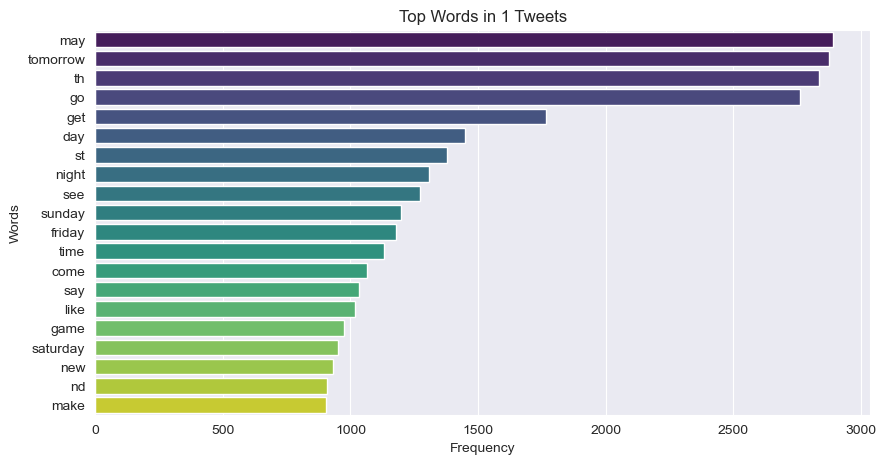

C:\Users\Arwa Mohamed\AppData\Local\Temp\ipykernel_1768\673335096.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(words), palette='viridis', hue=None, legend=False)


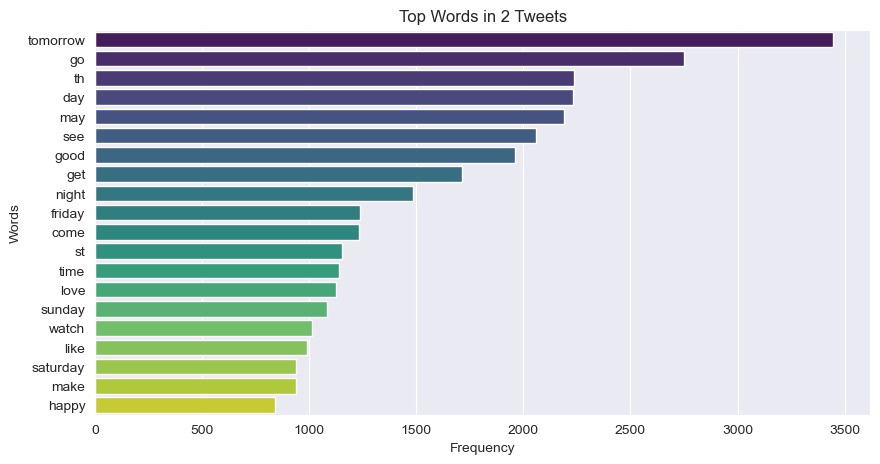

In [294]:
top_words = {}

for sentiment in [0,1,2]:
    tokens = df[df['label'] == sentiment]['extra_cleaned']
    top_words[sentiment] = get_top_words(tokens)

def plot_top_words(word_freq, sentiment):
    words, freqs = zip(*word_freq)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(freqs), y=list(words), palette='viridis', hue=None, legend=False)
    plt.title(f"Top Words in {sentiment} Tweets")
    plt.xlabel("Frequency")
    plt.ylabel("Words")
    plt.show()

# Plot for each sentiment
for sentiment in [0,1,2]:
    plot_top_words(top_words[sentiment], sentiment)


In [295]:
df['word_count2'] = df['extra_cleaned'].apply(len)

In [296]:
print(sum(df['word_count'])) #word count after cleaning
print(sum(df['word_count2'])) #word count after deep cleaning

1009876
496983


# **LSTM Model:**

In [297]:
from collections import Counter

#go through cleaned data and see how many times each word appeared
#all this to build our own vocabulary
vocab_counter = Counter()
for tokens in df_train['extra_cleaned']:
    vocab_counter.update(tokens)

#each word gets a unique index starting from 2
word2idx = {'<PAD>': 0, '<UNK>': 1}  # mapping 0 for padding, 1 for unknown words
for idx, (word, _) in enumerate(vocab_counter.items(), start=2):
    word2idx[word] = idx

#Show some examples
print(f"Vocabulary size: {len(word2idx)}")
print(f"Sample word2idx mapping: {list(word2idx.items())[:10]}")



Vocabulary size: 34573
Sample word2idx mapping: [('<PAD>', 0), ('<UNK>', 1), ('qt', 2), ('original', 3), ('draft', 4), ('th', 5), ('book', 6), ('remus', 7), ('lupin', 8), ('survive', 9)]


In [298]:
# Neural networks expect inputs of fixed size.
# Tweets shorter than 30 words will be padded, and longer ones will be cut to 30 words.
max_len = 30

def encode_and_pad(tokens, word2idx, max_len):
    encoded = [word2idx.get(word, word2idx['<UNK>']) for word in tokens]  # Convert words to ids
    if len(encoded) < max_len:
        # Pad if shorter
        encoded += [word2idx['<PAD>']] * (max_len - len(encoded))
    else:
        # Truncate if longer
        encoded = encoded[:max_len]
    return encoded


df_train['encoded'] = df_train['extra_cleaned'].apply(lambda x: encode_and_pad(x, word2idx, max_len))
df_val['encoded'] = df_val['extra_cleaned'].apply(lambda x: encode_and_pad(x, word2idx, max_len))
df_test['encoded'] = df_test['extra_cleaned'].apply(lambda x: encode_and_pad(x, word2idx, max_len))

print(df_train[['extra_cleaned', 'encoded']].head())



                                       extra_cleaned  \
0  [qt, original, draft, th, book, remus, lupin, ...   
1  [ben, smith, smith, concussion, remain, lineup...   
2  [sorry, bout, stream, last, night, crash, toni...   
3  [chase, headley, rbi, double, th, inning, davi...   
4  [alciato, bee, invest, million, january, anoth...   

                                             encoded  
0  [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 0, 0, 0, 0, 0...  
1  [12, 13, 13, 14, 15, 16, 17, 18, 0, 0, 0, 0, 0...  
2  [19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 3...  
3  [31, 32, 33, 34, 5, 35, 36, 37, 38, 39, 40, 41...  
4  [46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 0, 0,...  


In [299]:
import torch

# Extract labels
# converts the labels from a Pandas Series into a simple Python list
y_train = df_train['label'].tolist()
y_val = df_val['label'].tolist()
y_test = df_test['label'].tolist()

# Convert labels to torch tensors
# PyTorch models expect the labels in tensor format (not Pandas Series)
y_train = torch.tensor(y_train, dtype=torch.long) #dtype=torch.long makes sure the labels are integer
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print(y_train[:10])
print(y_val[:10])
print(y_test[:10])



tensor([2, 1, 1, 1, 2, 2, 2, 0, 2, 1])
tensor([1, 2, 0, 1, 1, 1, 2, 0, 2, 1])
tensor([1, 1, 1, 2, 0, 1, 1, 2, 1, 0])


In [300]:
# Extract inputs (encoded tweets)
X_train = df_train['encoded'].tolist()
X_val = df_val['encoded'].tolist()
X_test = df_test['encoded'].tolist()

# Convert inputs to tensors
X_train = torch.tensor(X_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)


In [301]:
from torch.utils.data import Dataset, DataLoader

class TwitterDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [302]:
# Create datasets
train_dataset = TwitterDataset(X_train, y_train)
val_dataset = TwitterDataset(X_val, y_val)
test_dataset = TwitterDataset(X_test, y_test)

# Create DataLoaders
batch_size = 64
#andomly shuffles the tweets in your dataset for each epoch
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [303]:
for batch in train_loader:
    inputs, labels = batch
    print(f"Inputs shape: {inputs.shape}")
    print(f"Labels shape: {labels.shape}")
    break


Inputs shape: torch.Size([64, 30])
Labels shape: torch.Size([64])


In [304]:
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, pad_idx, dropout_prob=0.2):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(p=dropout_prob)
        # single-layer unidirectional LSTM.
        self.lstm = nn.LSTM(embed_dim, hidden_dim,dropout=dropout_prob, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)          # [batch_size, max_len, embed_dim]
        #not depend too much on certain words
        embedded_dropout = self.dropout(embedded)
        _, (hidden, _) = self.lstm(embedded_dropout)   # hidden: [1, batch_size, hidden_dim]
        hidden = hidden.squeeze(0)             # [batch_size, hidden_dim]
        output = self.fc(hidden)               # [batch_size, output_dim]
        return output


In [305]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

vocab_size = len(word2idx) #number of unique words
embed_dim = 100   # Size of each word vector that represent each word
#words-->numbers fa bashoof length kol words ha7awelha l kam number
#hidden_dim controls how much information the LSTM can remember at each step
hidden_dim = 128  # Size of LSTM hidden state
output_dim = 3    # 3 classes: negative, neutral, positive
pad_idx = word2idx['<PAD>']
dropout_prob=0.2

model = LSTMClassifier(vocab_size, embed_dim, hidden_dim, output_dim,pad_idx,dropout_prob).to(device)


C:\Users\Arwa Mohamed\anaconda3\Lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


In [306]:
#functions that update the model’s weights after loss calc
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()


In [307]:
# Move a sample batch to the device
for inputs, labels in train_loader:
    inputs = inputs.to(device)
    labels = labels.to(device)
    outputs = model(inputs)
    print(f"Batch outputs shape: {outputs.shape}")
    break


Batch outputs shape: torch.Size([64, 3])


In [308]:
import matplotlib.pyplot as plt

def train_model(model, train_loader, val_loader, optimizer, criterion, device, num_epochs=10):
    train_acc_list = []
    val_acc_list = []

    for epoch in range(num_epochs):
        model.train()
        running_corrects = 0 #how many correct predictions so far
        total = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            #Gradients accumulate by default in PyTorch → must zero them every batch
            optimizer.zero_grad()
            outputs = model(inputs) #elly hytla3 mn elmodel


           #Computes the loss between the model's predictions and true labels
            loss = criterion(outputs, labels)
            loss.backward() #compute gradients wrt to weights
            optimizer.step()

           #input tweet → model → 3 logits → pick highest
            preds = outputs.argmax(dim=1)
            running_corrects += (preds == labels).sum().item()
            total += labels.size(0)

        train_accuracy = running_corrects / total
        train_acc_list.append(train_accuracy)

        # Validation phase
        model.eval()
        val_corrects = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                preds = outputs.argmax(dim=1)
                val_corrects += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_accuracy = val_corrects / val_total
        val_acc_list.append(val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs} - Train Acc: {train_accuracy:.4f} - Val Acc: {val_accuracy:.4f}")

    return train_acc_list, val_acc_list


In [309]:
num_epochs = 10  # or more later
train_acc_list, val_acc_list = train_model(model, train_loader, val_loader, optimizer, criterion, device, num_epochs)


Epoch 1/10 - Train Acc: 0.4521 - Val Acc: 0.4345
Epoch 2/10 - Train Acc: 0.4520 - Val Acc: 0.4520
Epoch 3/10 - Train Acc: 0.4545 - Val Acc: 0.4510
Epoch 4/10 - Train Acc: 0.4551 - Val Acc: 0.4345
Epoch 5/10 - Train Acc: 0.4570 - Val Acc: 0.4520
Epoch 6/10 - Train Acc: 0.4558 - Val Acc: 0.4425
Epoch 7/10 - Train Acc: 0.4484 - Val Acc: 0.4470
Epoch 8/10 - Train Acc: 0.4793 - Val Acc: 0.4870
Epoch 9/10 - Train Acc: 0.5325 - Val Acc: 0.5190
Epoch 10/10 - Train Acc: 0.5901 - Val Acc: 0.5790


In [310]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad(): #Turns off gradient tracking during testing
        #Because we are not training or updating weights, just predicting
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Print Classification Report
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, digits=4))

    # Print Confusion Matrix
    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))




### Class 0 (Negative):
- **True Positives (TP) = 1082**: These are the instances that where correctly predicted as **Negative**.
- **False Positives (FP) = 2793**: These are the instances where the model predicted **Neutral** but the true label was **Negative**.
- **False Negatives (FN) = 97**: These are the instances where the model predicted **Positive**, but the true label was **Negative**.

### Class 1 (Neutral):
- **True Positives (TP) = 5130**: These are the instances that where correctly predicted as **Neutral**.
- **False Positives (FP) = 459**: These are the instances where the model predicted **Negative**, but the true label was **Neutral**.
- **False Negatives (FN) = 348**: These are the instances where the model predicted **Positive**, but the true label was **Neutral**.

### Class 2 (Positive):
- **True Positives (TP) = 653**: These are the instances that where correctly predicted as **Positive**.
- **False Positives (FP) = 45**: These are the instances where the model predicted **Negative**, but the true label was **Positive**.
- **False Negatives (FN) = 1677**: These are the instances where the model predicted **Neutral**, but the true label was **Positive**.

### Summary:
- **Diagonal elements (TP)**: Correctly predicted instances for each class.
- **Off-diagonal elements (FP, FN)**: Misclassified instances where the model made errors.


In [311]:
evaluate_model(model, test_loader, device)


Classification Report:
              precision    recall  f1-score   support

           0     0.6822    0.2724    0.3893      3972
           1     0.5344    0.8641    0.6604      5937
           2     0.5947    0.2749    0.3760      2375

    accuracy                         0.5589     12284
   macro avg     0.6038    0.4705    0.4753     12284
weighted avg     0.5938    0.5589    0.5178     12284

Confusion Matrix:
[[1082 2793   97]
 [ 459 5130  348]
 [  45 1677  653]]


### 1. Precision: kam wahda mn elly 3amlnalhom prediction llclass dah kano sah
**Precision** how many of the predicted instances for a class were actually correct.
- It answers the question: *"Out of all the instances predicted as a certain class, how many were actually correct?"*
- **Formula**:
  `Precision = True Positives / (True Positives + False Positives)`

### 2. Recall: 3rfna n predict ad eh mn elclass dah
**Recall** measures how many of the actual instances of a class were found.
- It answers the question: *"Out of all the actual instances of a class, how many were correctly predicted?"*
- **Formula**:
  `Recall = True Positives / (True Positives + False Negatives)`

### 3. F1-Score:
- It balances both **precision** and **recall** into a single metric.
- **Formula**:
  `F1 = 2 * (Precision * Recall) / (Precision + Recall)`

### 4. Support:
- It represents how many **real samples** there are for each class.

-**Macro** Average gives you a fair evaluation across classes, especially when classes are imbalanced.

-**Weighted Average** gives you a realistic measure of how the model performs on actual data, considering that some classes may be much larger than others.


### MODEL 2

In [312]:
import torch.nn as nn

class ImprovedLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, pad_idx, dropout_prob=0.3):
        super(ImprovedLSTMClassifier, self).__init__()

        # 1. Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        # 2. Bidirectional 2-layer LSTM
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=3,
            dropout=dropout_prob,
            batch_first=True,
            bidirectional=True
            #LSTM captures relationships between words, and bidirectional allows the model to consider both past and future context meaning it learns from the sequence both forward and backward
        )

        # 3. Fully Connected Output Layer
        self.fc = nn.Linear(hidden_dim * 2, output_dim)  # hidden_dim*2 because of bidirectional

        # 4. Dropout
        self.dropout = nn.Dropout(p=dropout_prob)

    def forward(self, x):
        embedded = self.embedding(x)  # [batch_size, max_len, embed_dim]
        embedded = self.dropout(embedded)

        lstm_out, (hidden, _) = self.lstm(embedded)

        # Concatenate final forward and backward hidden states
        #The LSTM processes the entire sequence of words and returns the final hidden state, which summarizes the entire sequence
        hidden_forward = hidden[-2,:,:]  # Last hidden layer forward
        hidden_backward = hidden[-1,:,:] # Last hidden layer backward
        hidden_concat = torch.cat((hidden_forward, hidden_backward), dim=1)  # [batch_size, hidden_dim*2]

        hidden_concat = self.dropout(hidden_concat)
        output = self.fc(hidden_concat)  # [batch_size, output_dim]

        return output


In [313]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

vocab_size = len(word2idx)
embed_dim = 100        # (you can keep 100)
hidden_dim = 128       # (was 128 before)
output_dim = 3         # 3 classes
pad_idx = word2idx['<PAD>']
dropout_prob = 0.5

model = ImprovedLSTMClassifier(vocab_size, embed_dim, hidden_dim, output_dim, pad_idx, dropout_prob).to(device)


In [314]:
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

 #If your dataset is imbalanced, you can assign higher weight to the underrepresented classes.
 #L2 regularization (also called weight decay) helps prevent overfitting by penalizing large weights.
optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)


class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train.numpy()), y=y_train.numpy())
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)



In [315]:
import matplotlib.pyplot as plt
import torch

def train_model(model, train_loader, val_loader, optimizer, criterion, device, num_epochs=20, patience=3):
    train_acc_list = []
    val_acc_list = []

    best_val_acc = 0
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        running_corrects = 0
        total = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            preds = outputs.argmax(dim=1)
            running_corrects += (preds == labels).sum().item()
            total += labels.size(0)

        train_accuracy = running_corrects / total
        train_acc_list.append(train_accuracy)

        # Validation phase
        model.eval()
        val_corrects = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                preds = outputs.argmax(dim=1)
                val_corrects += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_accuracy = val_corrects / val_total
        val_acc_list.append(val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs} - Train Acc: {train_accuracy:.4f} - Val Acc: {val_accuracy:.4f}")

        # Early Stopping check
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            epochs_no_improve = 0
            # Save the best model
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {patience} epochs without improvement.")
                break

    # After training, plot the learning curves
    plt.plot(train_acc_list, label='Train Accuracy')
    plt.plot(val_acc_list, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.show()

    return train_acc_list, val_acc_list


Epoch 1/20 - Train Acc: 0.4076 - Val Acc: 0.5095
Epoch 2/20 - Train Acc: 0.4888 - Val Acc: 0.5730
Epoch 3/20 - Train Acc: 0.5291 - Val Acc: 0.5900
Epoch 4/20 - Train Acc: 0.5515 - Val Acc: 0.6245
Epoch 5/20 - Train Acc: 0.5759 - Val Acc: 0.6310
Epoch 6/20 - Train Acc: 0.5895 - Val Acc: 0.6075
Epoch 7/20 - Train Acc: 0.6002 - Val Acc: 0.6300
Epoch 8/20 - Train Acc: 0.6124 - Val Acc: 0.6445
Epoch 9/20 - Train Acc: 0.6216 - Val Acc: 0.6585
Epoch 10/20 - Train Acc: 0.6320 - Val Acc: 0.6560
Epoch 11/20 - Train Acc: 0.6446 - Val Acc: 0.6455
Epoch 12/20 - Train Acc: 0.6492 - Val Acc: 0.6550
Early stopping triggered after 3 epochs without improvement.


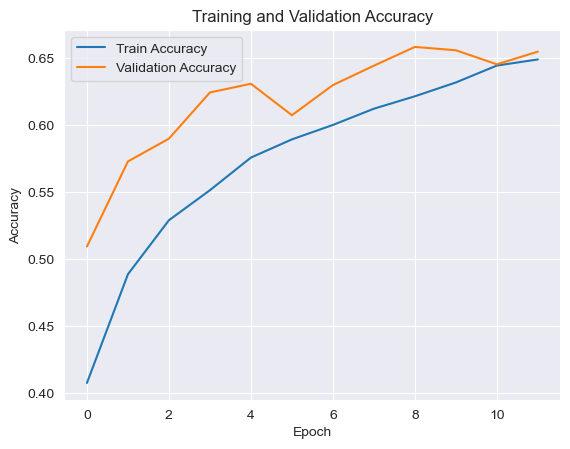

In [316]:
train_acc_list, val_acc_list = train_model(model, train_loader, val_loader, optimizer, criterion, device, num_epochs=20)


In [317]:
print("Evaluating Improved LSTM model:")
evaluate_model(model, test_loader, device)


Evaluating Improved LSTM model:
Classification Report:
              precision    recall  f1-score   support

           0     0.6345    0.5433    0.5854      3972
           1     0.6086    0.7320    0.6646      5937
           2     0.5930    0.4349    0.5018      2375

    accuracy                         0.6136     12284
   macro avg     0.6120    0.5701    0.5839     12284
weighted avg     0.6140    0.6136    0.6075     12284

Confusion Matrix:
[[2158 1626  188]
 [1070 4346  521]
 [ 173 1169 1033]]


### MODEL 3

In [318]:
class ImprovedLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, pad_idx, dropout_prob=0.6, pretrained_embeddings=None):
        super(ImprovedLSTMClassifier, self).__init__()

        if pretrained_embeddings is not None:
            self.embedding = nn.Embedding.from_pretrained(pretrained_embeddings, freeze=False, padding_idx=pad_idx)
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=3,   # <<< increased depth
            dropout=dropout_prob,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(p=dropout_prob)

    def forward(self, x):
        embedded = self.embedding(x)
        embedded = self.dropout(embedded)

        lstm_out, (hidden, _) = self.lstm(embedded)

        hidden_forward = hidden[-2, :, :]
        hidden_backward = hidden[-1, :, :]
        hidden_concat = torch.cat((hidden_forward, hidden_backward), dim=1)

        hidden_concat = self.dropout(hidden_concat)
        output = self.fc(hidden_concat)
        return output


In [319]:
def load_glove_embeddings(glove_path, word2idx, embed_dim):
    embeddings = np.random.uniform(-0.25, 0.25, (len(word2idx), embed_dim))  # random small values
    with open(glove_path, 'r', encoding='utf8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            if word in word2idx:
                embeddings[word2idx[word]] = vector
    return torch.tensor(embeddings, dtype=torch.float)


In [320]:
glove_path = 'glove.6B.100d.txt'  # make sure you downloaded this
pretrained_embeddings = load_glove_embeddings(glove_path, word2idx, embed_dim=100)

model = ImprovedLSTMClassifier(vocab_size, embed_dim=100, hidden_dim=128, output_dim=3, pad_idx=word2idx['<PAD>'], dropout_prob=0.5, pretrained_embeddings=pretrained_embeddings).to(device)


In [321]:
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)

# Weighted loss
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train.numpy()), y=y_train.numpy())
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)


Epoch 1/20 - Train Acc: 0.4968 - Val Acc: 0.5620
Epoch 2/20 - Train Acc: 0.5628 - Val Acc: 0.6025
Epoch 3/20 - Train Acc: 0.5941 - Val Acc: 0.6355
Epoch 4/20 - Train Acc: 0.6115 - Val Acc: 0.6515
Epoch 5/20 - Train Acc: 0.6302 - Val Acc: 0.6610
Epoch 6/20 - Train Acc: 0.6446 - Val Acc: 0.6680
Epoch 7/20 - Train Acc: 0.6543 - Val Acc: 0.6780
Epoch 8/20 - Train Acc: 0.6670 - Val Acc: 0.6640
Epoch 9/20 - Train Acc: 0.6812 - Val Acc: 0.6710
Epoch 10/20 - Train Acc: 0.6916 - Val Acc: 0.6705
Early stopping triggered after 3 epochs without improvement.


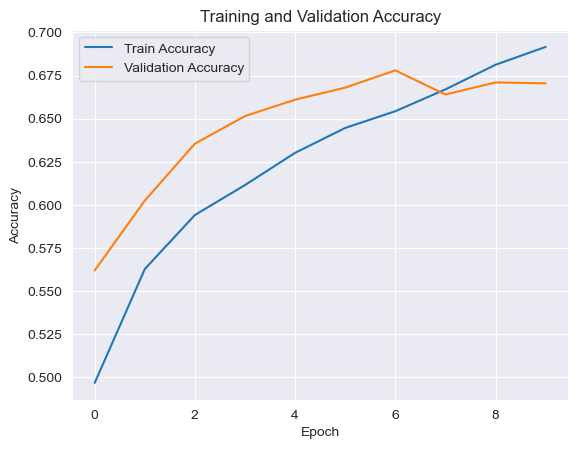

In [322]:
train_acc_list, val_acc_list = train_model(model, train_loader, val_loader, optimizer, criterion, device, num_epochs=20)


In [323]:
print("Evaluating Improved LSTM model:")
evaluate_model(model, test_loader, device)

Evaluating Improved LSTM model:
Classification Report:
              precision    recall  f1-score   support

           0     0.6335    0.6279    0.6307      3972
           1     0.6466    0.6761    0.6610      5937
           2     0.5923    0.5335    0.5614      2375

    accuracy                         0.6329     12284
   macro avg     0.6241    0.6125    0.6177     12284
weighted avg     0.6319    0.6329    0.6319     12284

Confusion Matrix:
[[2494 1268  210]
 [1261 4014  662]
 [ 182  926 1267]]


## Changes Between the 3 Models: Baseline LSTM, Improved LSTM, and Optimized LSTM

The following table summarizes the key differences between the **Baseline LSTM**, **Improved LSTM**, and **Optimized LSTM (with pre-trained embeddings)**. These differences in architecture and techniques directly impacted the model's performance.

### 1. **Baseline LSTM**
- **Layers**: Standard **1-layer LSTM**.
- **Embedding**: Trained word embeddings from scratch.
- **Regularization**: No dropout applied.
- **Class Weights**: Not used.
- **Performance**:
  - Accuracy: **55.89%**
  - Precision/Recall/F1-Score: not that Balanced and  not optimized for imbalanced classes.

### 2. **Improved LSTM**
- **Layers**: **3-layer LSTM** with **bidirectional** architecture.
- **Embedding**: Trained word embeddings from scratch.
- **Regularization**: **Dropout** applied to prevent overfitting.
- **Class Weights**: **Class weights** applied to handle class imbalance.
- **Performance**:
  - Accuracy: **61.36%**
  - Precision/Recall/F1-Score: Improved, especially for **Neutral** class.

### 3. **Optimized LSTM (with pre-trained embeddings)**
- **Layers**: Same as **Improved LSTM** (**3-layer LSTM**, bidirectional).
- **Embedding**: Uses **pre-trained GloVe embeddings** for better word representations.
- **Regularization**: **Dropout** applied.
- **Class Weights**: **Class weights** applied.
- **Performance**:
  - Accuracy: **63.29%**
  - Precision/Recall/F1-Score: Significant improvement in overall performance, especially for **Neutral** and **Positive** classes.

### **Key Differences**:
- **Model Depth**: The **Improved LSTM** and **Optimized LSTM** models are **deeper** (3 layers) compared to the **Baseline LSTM** (1 layer), allowing the model to capture more complex patterns.
- **Bidirectional LSTM**: Both **Improved LSTM** and **Optimized LSTM** use **bidirectional LSTM** to capture context from both **past** and **future** words, while the **Baseline LSTM** only considers the past.
- **Pre-trained Embeddings**: The **Optimized LSTM** uses **pre-trained GloVe embeddings**, which improve the model's ability to understand word meanings based on large external corpora.
- **Class Weights**: The **Improved LSTM** and **Optimized LSTM** both use **class weights** to handle **class imbalance**, improving performance for underrepresented classes like **Positive** and **Negative**.
- **Regularization**: **Dropout** is applied to the **Improved LSTM** and **Optimized LSTM** models to prevent overfitting, which is not done in the **Baseline LSTM**.

### **Summary of Changes**:
- The **deeper architecture**, **bidirectional LSTM**, and **pre-trained embeddings** in the **Improved LSTM** and **Optimized LSTM** led to better performance, especially for underrepresented classes.
- **Class weights** and **dropout** further improved generalization and prevented the model from overfitting.


## Comparison Table Between Different Model Versions

The following table summarizes the key differences between the **Baseline LSTM**, **Improved LSTM**, and **Optimized LSTM** models.

| **Model Version**           | **Accuracy** | **Precision** | **Recall** | **F1-Score** | **Key Changes**                                                                 |
|-----------------------------|--------------|---------------|------------|--------------|----------------------------------------------------------------------------------|
| **Baseline LSTM**            | 0.5589       | 0.5938        | 0.5589     | 0.5718       |  Standard 1-layer LSTM, trained from scratch, no dropout or class weights.       |
| **Improved LSTM**            | 0.6136       | 0.6140        | 0.6136     | 0.6075       |  3-layer bidirectional LSTM, dropout applied, class weights to address imbalance. |
| **Optimized LSTM (w/ Glove)**| 0.6329       | 0.6319        | 0.6329     | 0.6319       |  3-layer bidirectional LSTM, pre-trained GloVe embeddings, dropout, class weights. |

### **Key Changes**:
1. **LSTM Layers**:
   - The **Improved LSTM** and **Optimized LSTM** use **3 LSTM layers** compared to the **1 layer** in the **Baseline LSTM**, allowing them to capture more complex relationships in the data.
   - **Bidirectional LSTM** is used in both **Improved LSTM** and **Optimized LSTM**, meaning they capture information from both the **past** and the **future**.

2. **Pre-trained Embeddings**:
   - The **Optimized LSTM** uses **pre-trained GloVe embeddings**, which provides a better understanding of word meanings compared to training embeddings from scratch in the **Baseline LSTM** and **Improved LSTM**.

3. **Regularization**:
   - **Dropout** is used in both the **Improved LSTM** and **Optimized LSTM** to prevent overfitting, but is **not applied in the Baseline LSTM**.

4. **Class Weights**:
   - The **Improved LSTM** and **Optimized LSTM** use **class weights** to deal with **imbalanced data**, whereas the **Baseline LSTM** does not.

### **Summary**:
- The **Optimized LSTM** (with pre-trained embeddings) performs the best, improving both accuracy and F1-score over the **Baseline LSTM** and **Improved LSTM**.
- The **Improved LSTM** showed improvements over the **Baseline LSTM**, particularly due to its **deeper architecture** and **bidirectional nature**.
- The **RNN-based Model** performed the worst, as it struggles to capture long-range dependencies compared to the **LSTM** models.
